# HAM10000 con EfficientNet-B0
Versión corregida del cuaderno original, orientada a una evaluación más fiable y a un mejor rendimiento en clases minoritarias.

## Mejoras aplicadas
- **Split estricto por `lesion_id`** para evitar *data leakage*.
- **Separación train / val / test** a nivel de lesión.
- **Sin oversampling por duplicado de filas**.
- **`WeightedRandomSampler`** para compensar el desbalance en entrenamiento.
- **Pérdida Focal Loss** con pesos por clase.
- **Transforms correctas**: augmentación solo en train.
- **Métricas más informativas**: accuracy, balanced accuracy, macro F1, weighted F1, matriz de confusión y ROC-AUC OvR.
- **Checkpoint del mejor modelo** según `macro_f1` de validación.
- **EfficientNet-B0 preentrenada**.

In [1]:

# ============================================================
# 1. INSTALACIÓN / IMPORTS
# ============================================================
!pip -q install kagglehub scikit-learn seaborn

import os
import random
from pathlib import Path
from collections import Counter

import kagglehub
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

import torch
import torch.nn as nn
from torch.optim import AdamW
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms, models

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    balanced_accuracy_score,
    f1_score,
    roc_auc_score,
    accuracy_score
)
from sklearn.utils.class_weight import compute_class_weight

In [2]:

# ============================================================
# 2. SEMILLA Y DISPOSITIVO
# ============================================================
SEED = 42

def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Dispositivo:", device)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Dispositivo: cuda
GPU: Tesla T4


In [3]:

# ============================================================
# 3. DESCARGA HAM10000
# ============================================================
print("=" * 80)
print("DESCARGANDO HAM10000")
print("=" * 80)

data_dir = Path(kagglehub.dataset_download("kmader/skin-cancer-mnist-ham10000"))
print("Dataset descargado en:", data_dir)

all_image_paths = list(data_dir.glob("ham10000_images_part_1/*.jpg")) + list(data_dir.glob("ham10000_images_part_2/*.jpg"))
imageid_path_dict = {p.stem: str(p) for p in all_image_paths}

lesion_type_dict = {
    "nv": "Melanocytic nevi",
    "mel": "Melanoma",
    "bkl": "Benign keratosis-like lesions",
    "bcc": "Basal cell carcinoma",
    "akiec": "Actinic keratoses",
    "vasc": "Vascular lesions",
    "df": "Dermatofibroma",
}

metadata_path = data_dir / "HAM10000_metadata.csv"
df = pd.read_csv(metadata_path)

df["path"] = df["image_id"].map(imageid_path_dict)
df["cell_type"] = df["dx"].map(lesion_type_dict)

# Orden fijo de clases para reproducibilidad y lectura clara
CLASS_ORDER = ["akiec", "bcc", "bkl", "df", "nv", "vasc", "mel"]
IDX_TO_CLASS = {i: c for i, c in enumerate(CLASS_ORDER)}
CLASS_TO_IDX = {c: i for i, c in IDX_TO_CLASS.items()}

df["label"] = df["dx"].map(CLASS_TO_IDX)

print("Número total de muestras:", len(df))
print("Número de lesion_id únicos:", df["lesion_id"].nunique())
print(df["dx"].value_counts())
df.head()

DESCARGANDO HAM10000
Using Colab cache for faster access to the 'skin-cancer-mnist-ham10000' dataset.
Dataset descargado en: /kaggle/input/skin-cancer-mnist-ham10000
Número total de muestras: 10015
Número de lesion_id únicos: 7470
dx
nv       6705
mel      1113
bkl      1099
bcc       514
akiec     327
vasc      142
df        115
Name: count, dtype: int64


,lesion_id,image_id,dx,dx_type,age,sex,localization,path,cell_type,label
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp,/kaggle/input/skin-cancer-mnist-ham10000/ham10...,Benign keratosis-like lesions,2
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp,/kaggle/input/skin-cancer-mnist-ham10000/ham10...,Benign keratosis-like lesions,2
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp,/kaggle/input/skin-cancer-mnist-ham10000/ham10...,Benign keratosis-like lesions,2
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp,/kaggle/input/skin-cancer-mnist-ham10000/ham10...,Benign keratosis-like lesions,2
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear,/kaggle/input/skin-cancer-mnist-ham10000/ham10...,Benign keratosis-like lesions,2


In [4]:

# ============================================================
# 4. SPLIT ESTRICTO POR LESION_ID
#    Evita fuga de información entre train / val / test
# ============================================================
lesion_df = (
    df.groupby("lesion_id")
      .agg(dx=("dx", "first"))
      .reset_index()
)

train_lesions, temp_lesions = train_test_split(
    lesion_df,
    test_size=0.30,
    random_state=SEED,
    stratify=lesion_df["dx"]
)

val_lesions, test_lesions = train_test_split(
    temp_lesions,
    test_size=0.50,
    random_state=SEED,
    stratify=temp_lesions["dx"]
)

train_ids = set(train_lesions["lesion_id"])
val_ids = set(val_lesions["lesion_id"])
test_ids = set(test_lesions["lesion_id"])

train_df = df[df["lesion_id"].isin(train_ids)].copy().reset_index(drop=True)
val_df   = df[df["lesion_id"].isin(val_ids)].copy().reset_index(drop=True)
test_df  = df[df["lesion_id"].isin(test_ids)].copy().reset_index(drop=True)

assert train_ids.isdisjoint(val_ids)
assert train_ids.isdisjoint(test_ids)
assert val_ids.isdisjoint(test_ids)

print("Train imágenes:", len(train_df), "| lesion_id únicos:", train_df["lesion_id"].nunique())
print("Val imágenes:  ", len(val_df),   "| lesion_id únicos:", val_df["lesion_id"].nunique())
print("Test imágenes: ", len(test_df),  "| lesion_id únicos:", test_df["lesion_id"].nunique())

print("\nDistribución train:")
print(train_df["dx"].value_counts().sort_index())
print("\nDistribución val:")
print(val_df["dx"].value_counts().sort_index())
print("\nDistribución test:")
print(test_df["dx"].value_counts().sort_index())

Train imágenes: 6981 | lesion_id únicos: 5229
Val imágenes:   1532 | lesion_id únicos: 1120
Test imágenes:  1502 | lesion_id únicos: 1121

Distribución train:
dx
akiec     222
bcc       361
bkl       772
df         71
mel       773
nv       4683
vasc       99
Name: count, dtype: int64

Distribución val:
dx
akiec      53
bcc        82
bkl       160
df         24
mel       173
nv       1018
vasc       22
Name: count, dtype: int64

Distribución test:
dx
akiec      52
bcc        71
bkl       167
df         20
mel       167
nv       1004
vasc       21
Name: count, dtype: int64


In [5]:

# ============================================================
# 5. NORMALIZACIÓN
#    Puedes usar ImageNet porque EfficientNet viene preentrenada
# ============================================================
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

IMG_SIZE = 224

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.10, contrast=0.10, saturation=0.10, hue=0.02),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

In [6]:

# ============================================================
# 6. DATASET
# ============================================================
class HAM10000Dataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image = Image.open(row["path"]).convert("RGB")
        label = int(row["label"])
        if self.transform:
            image = self.transform(image)
        return image, label

train_dataset = HAM10000Dataset(train_df, transform=train_transform)
val_dataset   = HAM10000Dataset(val_df, transform=eval_transform)
test_dataset  = HAM10000Dataset(test_df, transform=eval_transform)

In [7]:

# ============================================================
# 7. BALANCEO CORRECTO: WeightedRandomSampler
# ============================================================
train_labels = train_df["label"].values
class_sample_count = np.array([(train_labels == i).sum() for i in range(len(CLASS_ORDER))])
class_weights_sampler = 1.0 / class_sample_count
sample_weights = class_weights_sampler[train_labels]
sample_weights = torch.DoubleTensor(sample_weights)

sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

BATCH_SIZE = 32
NUM_WORKERS = 2

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    sampler=sampler,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

print("Conteo por clase en train:", class_sample_count)
print("Pesos sampler por clase:", class_weights_sampler)

Conteo por clase en train: [ 222  361  772   71 4683   99  773]
Pesos sampler por clase: [0.0045045  0.00277008 0.00129534 0.01408451 0.00021354 0.01010101
 0.00129366]


In [8]:

# ============================================================
# 8. PÉRDIDA: Focal Loss + pesos por clase
# ============================================================
class_weights_loss = compute_class_weight(
    class_weight="balanced",
    classes=np.arange(len(CLASS_ORDER)),
    y=train_labels
)
class_weights_loss = torch.tensor(class_weights_loss, dtype=torch.float32, device=device)

class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2.0, reduction="mean"):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction
        self.ce = nn.CrossEntropyLoss(reduction="none")

    def forward(self, logits, targets):
        ce_loss = self.ce(logits, targets)
        pt = torch.exp(-ce_loss)
        focal = (1 - pt) ** self.gamma * ce_loss

        if self.alpha is not None:
            alpha_t = self.alpha[targets]
            focal = alpha_t * focal

        if self.reduction == "mean":
            return focal.mean()
        if self.reduction == "sum":
            return focal.sum()
        return focal

criterion = FocalLoss(alpha=class_weights_loss, gamma=2.0)
print("Pesos por clase para la loss:", class_weights_loss)

Pesos por clase para la loss: tensor([ 4.4923,  2.7626,  1.2918, 14.0463,  0.2130, 10.0736,  1.2901],
       device='cuda:0')


In [9]:

# ============================================================
# 9. MODELO: EfficientNet-B0
# ============================================================
weights = models.EfficientNet_B0_Weights.DEFAULT
model = models.efficientnet_b0(weights=weights)

in_features = model.classifier[1].in_features
model.classifier[1] = nn.Linear(in_features, len(CLASS_ORDER))
model = model.to(device)

optimizer = AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)

# Scheduler opcional
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=2
)

print(model)

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 135MB/s] 


EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActivat

In [10]:

# ============================================================
# 10. UTILIDADES DE EVALUACIÓN
# ============================================================
def run_one_epoch(model, loader, criterion=None, optimizer=None, train=False):
    if train:
        model.train()
    else:
        model.eval()

    losses = []
    all_labels = []
    all_preds = []
    all_probs = []

    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        if train:
            optimizer.zero_grad()

        with torch.set_grad_enabled(train):
            logits = model(images)
            probs = torch.softmax(logits, dim=1)
            preds = torch.argmax(probs, dim=1)

            if criterion is not None:
                loss = criterion(logits, labels)
                losses.append(loss.item())

            if train:
                loss.backward()
                optimizer.step()

        all_labels.extend(labels.detach().cpu().numpy())
        all_preds.extend(preds.detach().cpu().numpy())
        all_probs.extend(probs.detach().cpu().numpy())

    all_labels = np.array(all_labels)
    all_preds = np.array(all_preds)
    all_probs = np.array(all_probs)

    metrics = {
        "loss": float(np.mean(losses)) if losses else None,
        "accuracy": accuracy_score(all_labels, all_preds),
        "balanced_accuracy": balanced_accuracy_score(all_labels, all_preds),
        "macro_f1": f1_score(all_labels, all_preds, average="macro"),
        "weighted_f1": f1_score(all_labels, all_preds, average="weighted"),
    }

    try:
        metrics["roc_auc_ovr"] = roc_auc_score(
            all_labels,
            all_probs,
            multi_class="ovr",
            average="macro"
        )
    except Exception:
        metrics["roc_auc_ovr"] = np.nan

    return metrics, all_labels, all_preds, all_probs


def print_metrics(title, metrics):
    print(f"\n{title}")
    print("-" * len(title))
    for k, v in metrics.items():
        print(f"{k:>18}: {v:.4f}" if v is not None and not (isinstance(v, float) and np.isnan(v)) else f"{k:>18}: NaN")

In [11]:

# ============================================================
# 11. ENTRENAMIENTO
# ============================================================
EPOCHS = 12
best_macro_f1 = -1
history = {
    "train_loss": [],
    "val_loss": [],
    "train_acc": [],
    "val_acc": [],
    "train_macro_f1": [],
    "val_macro_f1": [],
    "train_bal_acc": [],
    "val_bal_acc": [],
}

best_model_path = "best_efficientnet_b0_ham10000.pth"

for epoch in range(1, EPOCHS + 1):
    print(f"\n{'='*25} Epoch {epoch}/{EPOCHS} {'='*25}")

    train_metrics, _, _, _ = run_one_epoch(
        model, train_loader, criterion=criterion, optimizer=optimizer, train=True
    )
    val_metrics, val_labels, val_preds, val_probs = run_one_epoch(
        model, val_loader, criterion=criterion, optimizer=None, train=False
    )

    history["train_loss"].append(train_metrics["loss"])
    history["val_loss"].append(val_metrics["loss"])
    history["train_acc"].append(train_metrics["accuracy"])
    history["val_acc"].append(val_metrics["accuracy"])
    history["train_macro_f1"].append(train_metrics["macro_f1"])
    history["val_macro_f1"].append(val_metrics["macro_f1"])
    history["train_bal_acc"].append(train_metrics["balanced_accuracy"])
    history["val_bal_acc"].append(val_metrics["balanced_accuracy"])

    print_metrics("TRAIN", train_metrics)
    print_metrics("VAL", val_metrics)

    scheduler.step(val_metrics["macro_f1"])

    if val_metrics["macro_f1"] > best_macro_f1:
        best_macro_f1 = val_metrics["macro_f1"]
        torch.save({
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "best_macro_f1": best_macro_f1,
            "class_order": CLASS_ORDER,
            "img_size": IMG_SIZE
        }, best_model_path)
        print(f"\n✅ Nuevo mejor modelo guardado en: {best_model_path}")


========================= Epoch 1/12 =========================

TRAIN
-----
              loss: 2.0085
          accuracy: 0.4708
 balanced_accuracy: 0.4731
          macro_f1: 0.4010
       weighted_f1: 0.3994
       roc_auc_ovr: 0.8451

VAL
---
              loss: 0.8588
          accuracy: 0.2154
 balanced_accuracy: 0.5688
          macro_f1: 0.2579
       weighted_f1: 0.1560
       roc_auc_ovr: 0.8487

✅ Nuevo mejor modelo guardado en: best_efficientnet_b0_ham10000.pth

========================= Epoch 2/12 =========================

TRAIN
-----
              loss: 0.6215
          accuracy: 0.6902
 balanced_accuracy: 0.6853
          macro_f1: 0.6464
       weighted_f1: 0.6492
       roc_auc_ovr: 0.9491

VAL
---
              loss: 0.7147
          accuracy: 0.4308
 balanced_accuracy: 0.6507
          macro_f1: 0.4091
       weighted_f1: 0.4519
       roc_auc_ovr: 0.8990

✅ Nuevo mejor modelo guardado en: best_efficientnet_b0_ham10000.pth

========================= Epoch 3/12 ====

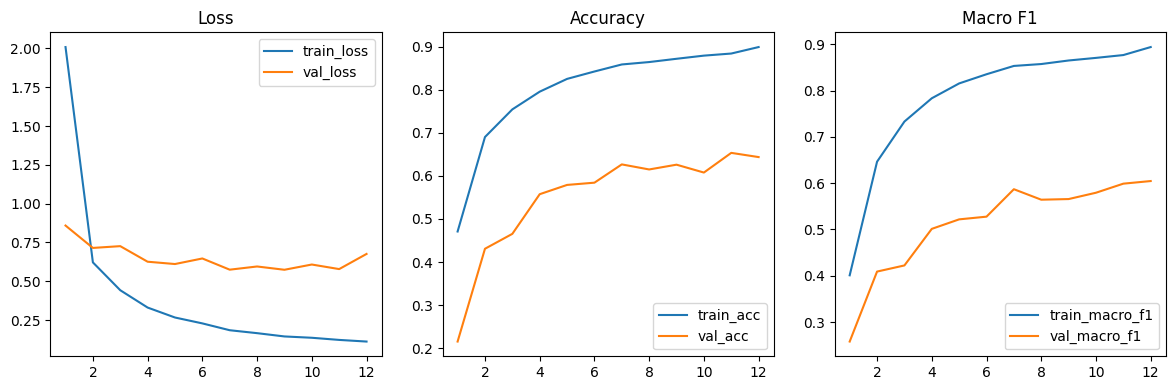

In [12]:

# ============================================================
# 12. CURVAS DE ENTRENAMIENTO
# ============================================================
epochs_range = range(1, len(history["train_loss"]) + 1)

plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.plot(epochs_range, history["train_loss"], label="train_loss")
plt.plot(epochs_range, history["val_loss"], label="val_loss")
plt.title("Loss")
plt.legend()

plt.subplot(1, 3, 2)
plt.plot(epochs_range, history["train_acc"], label="train_acc")
plt.plot(epochs_range, history["val_acc"], label="val_acc")
plt.title("Accuracy")
plt.legend()

plt.subplot(1, 3, 3)
plt.plot(epochs_range, history["train_macro_f1"], label="train_macro_f1")
plt.plot(epochs_range, history["val_macro_f1"], label="val_macro_f1")
plt.title("Macro F1")
plt.legend()

plt.tight_layout()
plt.show()

In [13]:

# ============================================================
# 13. CARGAR MEJOR MODELO Y EVALUAR EN TEST
# ============================================================
checkpoint = torch.load(best_model_path, map_location=device)
model.load_state_dict(checkpoint["model_state_dict"])
print("Mejor modelo cargado. Mejor macro_f1 val:", checkpoint["best_macro_f1"])

test_metrics, test_labels, test_preds, test_probs = run_one_epoch(
    model, test_loader, criterion=criterion, optimizer=None, train=False
)

print_metrics("TEST", test_metrics)

Mejor modelo cargado. Mejor macro_f1 val: 0.6046477679578783

TEST
----
              loss: 0.5145
          accuracy: 0.6365
 balanced_accuracy: 0.6916
          macro_f1: 0.5989
       weighted_f1: 0.6725
       roc_auc_ovr: 0.9419


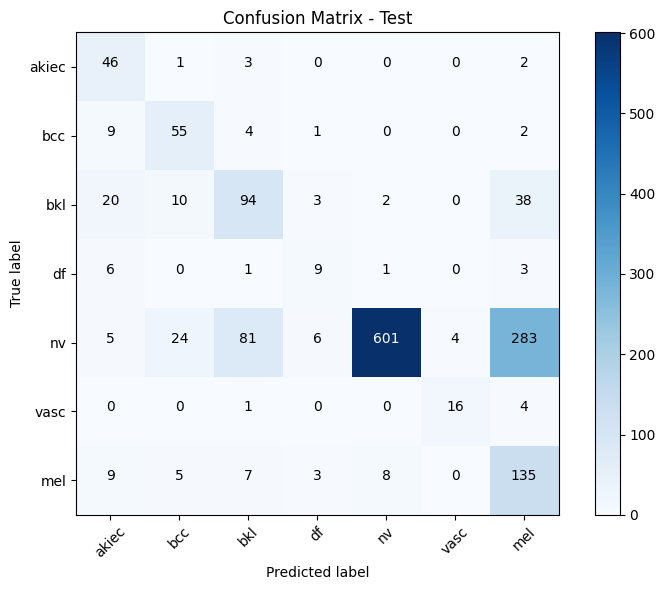

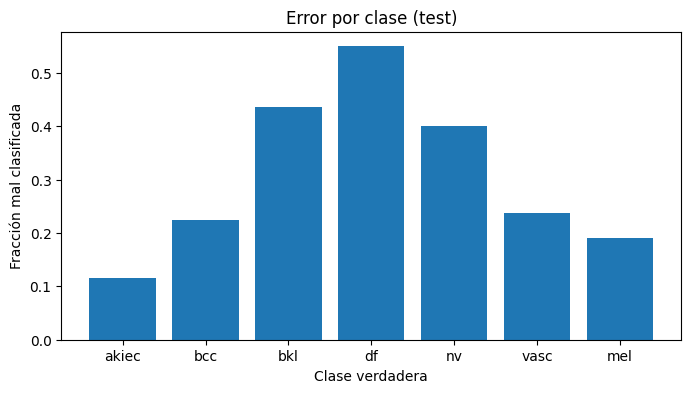

In [14]:

# ============================================================
# 14. MATRIZ DE CONFUSIÓN
# ============================================================
cm = confusion_matrix(test_labels, test_preds)

plt.figure(figsize=(8, 6))
plt.imshow(cm, interpolation="nearest", cmap=plt.cm.Blues)
plt.title("Confusion Matrix - Test")
plt.colorbar()
tick_marks = np.arange(len(CLASS_ORDER))
plt.xticks(tick_marks, CLASS_ORDER, rotation=45)
plt.yticks(tick_marks, CLASS_ORDER)

thresh = cm.max() / 2.0
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, format(cm[i, j], "d"),
                 ha="center",
                 color="white" if cm[i, j] > thresh else "black")

plt.ylabel("True label")
plt.xlabel("Predicted label")
plt.tight_layout()
plt.show()

label_frac_error = 1 - np.diag(cm) / np.sum(cm, axis=1)
plt.figure(figsize=(8, 4))
plt.bar(np.arange(len(CLASS_ORDER)), label_frac_error)
plt.xticks(np.arange(len(CLASS_ORDER)), CLASS_ORDER)
plt.xlabel("Clase verdadera")
plt.ylabel("Fracción mal clasificada")
plt.title("Error por clase (test)")
plt.show()

In [15]:

# ============================================================
# 15. INFORME DE CLASIFICACIÓN
# ============================================================
print(classification_report(
    test_labels,
    test_preds,
    target_names=CLASS_ORDER,
    digits=4
))

              precision    recall  f1-score   support

       akiec     0.4842    0.8846    0.6259        52
         bcc     0.5789    0.7746    0.6627        71
         bkl     0.4921    0.5629    0.5251       167
          df     0.4091    0.4500    0.4286        20
          nv     0.9820    0.5986    0.7438      1004
        vasc     0.8000    0.7619    0.7805        21
         mel     0.2891    0.8084    0.4259       167

    accuracy                         0.6365      1502
   macro avg     0.5765    0.6916    0.5989      1502
weighted avg     0.8041    0.6365    0.6725      1502



In [16]:

# ============================================================
# 16. INFERENCIA SOBRE UNA IMAGEN
# ============================================================
def predict_image(image_path, model, transform, class_order):
    model.eval()
    image = Image.open(image_path).convert("RGB")
    x = transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        logits = model(x)
        probs = torch.softmax(logits, dim=1).cpu().numpy()[0]
        pred_idx = int(np.argmax(probs))

    return {
        "pred_idx": pred_idx,
        "pred_class": class_order[pred_idx],
        "probs": {class_order[i]: float(probs[i]) for i in range(len(class_order))}
    }

# Ejemplo:
# sample_path = test_df.iloc[0]["path"]
# result = predict_image(sample_path, model, eval_transform, CLASS_ORDER)
# print(sample_path)
# print(result)

## Notas finales
- Este cuaderno está pensado para una evaluación **más honesta** que la versión original.
- La **accuracy sola no basta** en HAM10000; presta atención a:
  - `balanced_accuracy`
  - `macro_f1`
  - `recall` de `mel`
  - errores entre `mel` y `nv`
- Si quieres exprimir más el rendimiento:
  - probar **EfficientNet-B2/B3**
  - usar **mixup / cutmix**
  - aplicar **TTA**
  - congelar y descongelar capas por fases
  - probar **StratifiedGroupKFold** por `lesion_id`